# 02 — First model: a text baseline

Goal: train a **simple** scam detector and measure it honestly. Nothing is tuned here —
this is the **baseline**, the score that every later version has to beat.

Plan: combine text → remove duplicates → split train/test → dumb baseline →
TF-IDF → logistic regression → evaluate → look at the top clues.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

DATA_PATH = Path("..") / "data" / "fake_job_postings.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} postings")

Loaded 17,880 postings


## 1. Combine the text fields into one column

The model will read one block of text per posting. Blank fields are filled with `""`
(empty text) so joining them never fails or inserts the word "nan".

In [2]:
TEXT_COLUMNS = ["title", "company_profile", "description", "requirements", "benefits"]

# fillna("") swaps blanks for empty text; the join puts a space between fields.
df["text"] = df[TEXT_COLUMNS].fillna("").agg(" ".join, axis=1)

print(df.loc[0, "text"][:500], "...")

Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributor ...


**What this tells us:** Each posting is now a single block of text the model can read, starting with the title and running through the benefits. This is the only input this baseline uses — the yes/no fields from notebook 01 (like `has_company_logo`) are deliberately left out for now.

## 2. Check for duplicate postings

Every row has a unique `job_id`, so we look for postings whose **combined text** is identical —
the same ad posted more than once. Duplicates matter because if one copy lands in training
and another in testing, the model gets graded on an ad it already saw.

In [3]:
dup_mask = df.duplicated(subset="text", keep="first")  # True for 2nd, 3rd... copies
print(f"Duplicate postings (extra copies): {dup_mask.sum():,}")
print(f"  of which labelled fake: {df.loc[dup_mask, 'fraudulent'].sum():,}")

# Same text labelled BOTH fake and real somewhere: the labels disagree with each other.
labels_per_text = df.groupby("text")["fraudulent"].nunique()
print(f"Texts with conflicting labels: {(labels_per_text > 1).sum():,}")

Duplicate postings (extra copies): 1,814
  of which labelled fake: 148
Texts with conflicting labels: 0


**What this tells us:** 1,814 postings (about 10%) are extra copies of an ad that already appears, 148 of them fake, and no identical text carries conflicting labels. Removing them means the test set can't contain near-free answers the model already memorised during training, and keeping the first copy loses no label information.

In [4]:
# Keep the first copy of each posting, drop the rest.
before = len(df)
df = df.drop_duplicates(subset="text", keep="first").reset_index(drop=True)
print(f"{before:,} -> {len(df):,} postings after removing duplicates")

17,880 -> 16,066 postings after removing duplicates


## 3. Split into train (80%) and test (20%)

- **Train**: what the model learns from. **Test**: held back, like an exam it has never seen.
- `stratify` keeps the same fake/real mix in both parts.
- `random_state=42` fixes the shuffle so results are repeatable.

In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["text"],
    df["fraudulent"],
    test_size=0.20,
    stratify=df["fraudulent"],
    random_state=42,
)

for name, y in [("Train", y_train), ("Test", y_test)]:
    print(f"{name}: {len(y):,} postings, {y.mean() * 100:.2f}% fake")

Train: 12,852 postings, 4.47% fake
Test: 3,214 postings, 4.48% fake


**What this tells us:** After removing duplicates, both parts have almost exactly the same fake rate (4.47% train, 4.48% test), so stratifying worked. The test set holds only about 144 fake postings, so each scam caught or missed moves recall by about 0.7 percentage points — small changes later shouldn't be over-read.

## 4. Dumb baseline: always predict "real"

- **Accuracy** = share of all predictions that are right.
- **Recall (fake)** = share of actual scams the model catches.

In [6]:
dumb_predictions = [0] * len(y_test)  # 0 = real, for every posting

print(f"Accuracy:      {accuracy_score(y_test, dumb_predictions) * 100:.1f}%")
print(f"Recall (fake): {recall_score(y_test, dumb_predictions, zero_division=0) * 100:.1f}%")

Accuracy:      95.5%
Recall (fake): 0.0%


**What this tells us:** A "model" that never flags anything scores 95.5% accuracy while catching 0% of scams. Accuracy rewards getting the common answer right, so on imbalanced data it hides total failure — from here on we judge models by recall, precision and PR-AUC instead.

## 5. Turn text into numbers with TF-IDF

TF-IDF scores each word: higher when it appears often **in this posting**, lower when it
appears in **lots of postings** (so "the" scores near zero).

- `ngram_range=(1, 2)`: single words *and* two-word phrases ("work from", "from home").
- `max_features=20000`: keep only the 20,000 most frequent words/phrases.
- **Fit on train only.** The vectorizer learns its vocabulary and word-rarity from training
  postings alone. Letting it see the test postings would leak exam information into the
  study material (**leakage**) and make results look better than they'll be on new postings.
  The test text is only *transformed* using what was learned from training.

In [7]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)

X_train = vectorizer.fit_transform(X_train_text)  # learn vocabulary + convert
X_test = vectorizer.transform(X_test_text)        # convert only, nothing learned

print(f"Train matrix: {X_train.shape[0]:,} postings x {X_train.shape[1]:,} features")
print(f"Test matrix:  {X_test.shape[0]:,} postings x {X_test.shape[1]:,} features")

Train matrix: 12,852 postings x 20,000 features
Test matrix:  3,214 postings x 20,000 features


**What this tells us:** Each posting is now a row of 20,000 numbers, one per word or phrase in the vocabulary learned from training text only. Both matrices have the same 20,000 columns, which is exactly what we want: test postings are described using the training vocabulary, and anything new in them is simply ignored.

## 6. Train logistic regression

Logistic regression learns a **weight** per word/phrase: positive pushes toward "fake",
negative toward "real". It adds them up and turns the total into a probability.

`class_weight="balanced"`: fakes are only ~5% of the data, so the model could mostly ignore
them. "Balanced" makes each mistake on a fake count roughly 20x more than a mistake on a real
posting, forcing it to pay attention to scams.

In [8]:
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 7. Evaluate on the test set

- **Confusion matrix**: predictions vs. truth — scams caught, scams missed, false alarms.
- **Precision (fake)**: when it says "fake", how often it's right.
- **Recall (fake)**: of all real scams, how many it caught.
- **PR-AUC**: one 0–1 score for the precision/recall trade-off across every cut-off.
  Random guessing scores about the fake rate (~0.05).

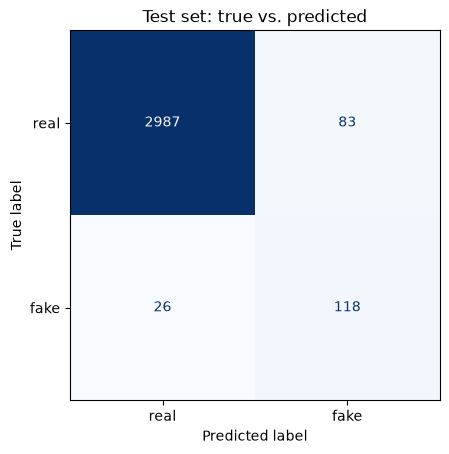

Precision (fake): 58.7%
Recall (fake):    81.9%
PR-AUC:           0.819
(random-guess PR-AUC is about 0.045)


In [9]:
y_pred = model.predict(X_test)                 # 0/1 decision (cut-off 0.5)
y_prob = model.predict_proba(X_test)[:, 1]     # probability of "fake"

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["real", "fake"]).plot(cmap="Blues", colorbar=False)
plt.title("Test set: true vs. predicted")
plt.show()

print(f"Precision (fake): {precision_score(y_test, y_pred) * 100:.1f}%")
print(f"Recall (fake):    {recall_score(y_test, y_pred) * 100:.1f}%")
print(f"PR-AUC:           {average_precision_score(y_test, y_prob):.3f}")
print(f"(random-guess PR-AUC is about {y_test.mean():.3f})")

**What this tells us:** The model catches 118 of 144 test scams (81.9% recall) but also raises 83 false alarms, so only 58.7% of its "fake" flags are right; it misses 26 scams. A PR-AUC of 0.819 against a random-guess score of about 0.045 shows the text carries a strong signal, and that number is the baseline later versions have to beat.

## 8. Which words and phrases drive the decision?

Each feature's weight shows which way it pushes: the biggest positive weights are the strongest
"fake" clues, the most negative are the strongest "real" clues.

In [10]:
weights = pd.Series(model.coef_[0], index=vectorizer.get_feature_names_out())

top_fake = weights.sort_values(ascending=False).head(15)
top_real = weights.sort_values(ascending=True).head(15)

pd.DataFrame({
    "toward FAKE": top_fake.index,
    "weight ": top_fake.values.round(2),
    "toward REAL": top_real.index,
    "weight": top_real.values.round(2),
})

,toward FAKE,weight,toward REAL,weight
0,link,4.03,our,-3.78
1,accion,3.65,in,-2.92
2,assistant,3.23,web,-2.78
3,earn,3.12,of,-2.54
4,data entry,3.08,it,-2.50
5,engineering,3.08,marketing,-2.39
6,below,3.00,digital,-2.34
7,aptitude staffing,2.77,companies,-2.26
8,offshore,2.70,is,-2.20
9,novation,2.70,team,-2.18


**What this tells us:** Some "fake" clues look like genuine scam language ("earn", "data entry", "link", "000" from money amounts), but several are specific company or agency names ("accion", "aptitude staffing", "novation") and oil-and-gas terms ("subsea", "offshore") from a cluster of fake ads in this dataset. That means part of the score comes from memorising *who* posted the scams in 2012–2014 rather than *how* scams read, so the model may do worse on new postings — a key thing to fix in a later version.